In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf

In [5]:
import re

In [6]:
import contractions

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
pd.read_csv(r"C:\Users\smara\Desktop\capstone2\archive (2)\go_emotions_dataset.csv")


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211220,ee6pagw,Everyone likes [NAME].,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
211221,ef28nod,Well when you’ve imported about a gazillion of...,False,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
211222,ee8hse1,That looks amazing,False,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
211223,edrhoxh,The FDA has plenty to criticize. But like here...,False,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
data=pd.read_csv(r"C:\Users\smara\Desktop\capstone2\archive (2)\go_emotions_dataset.csv")


In [10]:
data.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [11]:
data.shape

(211225, 31)

In [12]:
data.size

6547975

In [13]:
data.describe()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
count,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,...,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000
mean,0.081103,0.043768,0.038272,0.064472,0.083418,0.028401,0.034840,0.045885,0.018071,0.040095,...,0.038779,0.008569,0.041259,0.006164,0.041591,0.006102,0.011954,0.031994,0.026105,0.261797
std,0.272994,0.204580,0.191853,0.245592,0.276514,0.166116,0.183374,0.209236,0.133208,0.196182,...,0.193067,0.092172,0.198890,0.078269,0.199653,0.077880,0.108679,0.175985,0.159448,0.439614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    211225 non-null  object
 1   text                  211225 non-null  object
 2   example_very_unclear  211225 non-null  bool  
 3   admiration            211225 non-null  int64 
 4   amusement             211225 non-null  int64 
 5   anger                 211225 non-null  int64 
 6   annoyance             211225 non-null  int64 
 7   approval              211225 non-null  int64 
 8   caring                211225 non-null  int64 
 9   confusion             211225 non-null  int64 
 10  curiosity             211225 non-null  int64 
 11  desire                211225 non-null  int64 
 12  disappointment        211225 non-null  int64 
 13  disapproval           211225 non-null  int64 
 14  disgust               211225 non-null  int64 
 15  embarrassment    

In [15]:

data.isna().sum().sum()

np.int64(0)

In [16]:
data.drop('id',axis=1)

,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,False,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,False,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211220,Everyone likes [NAME].,False,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
211221,Well when you’ve imported about a gazillion of...,False,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
211222,That looks amazing,False,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
211223,The FDA has plenty to criticize. But like here...,False,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:

data.drop('id',axis=1,inplace=True)

In [18]:
data.drop('example_very_unclear',axis=1,inplace=True)

In [19]:
data.columns

Index(['text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval',
       'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
       'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
       'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='object')

In [20]:
emotional_cols=data.columns[1:]

In [21]:
emotional_cols

Index(['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='object')

In [22]:
emotion_cols = data.columns[2:]

def get_single_label(row):
    active = [col for col in emotion_cols if row[col] == 1]
    return active[0] if len(active) > 0 else None

data['emotion'] = data.apply(get_single_label, axis=1) 

In [23]:
df = data[['text', 'emotion']].dropna()


In [24]:
df

,text,emotion
0,That game hurt.,sadness
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral
5,Right? Considering it’s such an important docu...,gratitude
...,...,...
211218,"Thanks, [NAME]",gratitude
211219,"Well, I'm glad you're out of all that now. How...",joy
211220,Everyone likes [NAME].,love
211221,Well when you’ve imported about a gazillion of...,caring


In [25]:
df.head()

,text,emotion
0,That game hurt.,sadness
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral
5,Right? Considering it’s such an important docu...,gratitude


In [26]:
df.shape

(197283, 2)

### REDUCE EMOTIONS

In [27]:
red_emotions= {
    "joy": "happy",
    "love": "happy",
    "amusement": "happy",
    "admiration": "happy",
    "gratitude": "happy",
    "optimism": "happy",
    "pride": "happy",
    "relief": "happy",
    "excitement": "happy",
    
    "sadness": "sad",
    "grief": "sad",
    "remorse": "sad",
    "disappointment": "sad",
    "embarrassment": "sad",

    "anger": "stress",
    "annoyance": "stress",
    "disapproval": "stress",
    "disgust": "stress",

    "fear": "anxiety",
    "nervousness": "anxiety",
    "confusion": "anxiety",
    "realization": "anxiety"
}

In [28]:
red_emotions

{'joy': 'happy',
 'love': 'happy',
 'amusement': 'happy',
 'admiration': 'happy',
 'gratitude': 'happy',
 'optimism': 'happy',
 'pride': 'happy',
 'relief': 'happy',
 'excitement': 'happy',
 'sadness': 'sad',
 'grief': 'sad',
 'remorse': 'sad',
 'disappointment': 'sad',
 'embarrassment': 'sad',
 'anger': 'stress',
 'annoyance': 'stress',
 'disapproval': 'stress',
 'disgust': 'stress',
 'fear': 'anxiety',
 'nervousness': 'anxiety',
 'confusion': 'anxiety',
 'realization': 'anxiety'}

In [29]:
df=df[df['emotion'].isin(red_emotions.keys())]

In [30]:
df

,text,emotion
0,That game hurt.,sadness
3,Man I love reddit.,love
5,Right? Considering it’s such an important docu...,gratitude
6,"He isn't as big, but he's still quite popular....",disapproval
7,That's crazy; I went to a super [RELIGION] hig...,amusement
...,...,...
211217,You got banned for participating in a brigade.,annoyance
211218,"Thanks, [NAME]",gratitude
211219,"Well, I'm glad you're out of all that now. How...",joy
211220,Everyone likes [NAME].,love


In [31]:
df['emotion']=df['emotion'].map(red_emotions)

In [32]:
df

,text,emotion
0,That game hurt.,sad
3,Man I love reddit.,happy
5,Right? Considering it’s such an important docu...,happy
6,"He isn't as big, but he's still quite popular....",stress
7,That's crazy; I went to a super [RELIGION] hig...,happy
...,...,...
211217,You got banned for participating in a brigade.,stress
211218,"Thanks, [NAME]",happy
211219,"Well, I'm glad you're out of all that now. How...",happy
211220,Everyone likes [NAME].,happy


### Text Normalization

In [33]:
def nlp_pipeline(d):
    d=d.map(lambda x:x.lower())
    d=d.map(lambda x:re.sub("<.+?>","",x))
    d=d.map(lambda x:re.sub("<www[.]\S+|https?[:][//]\S+","",x))
    d=d.map(lambda x: contractions.fix(x))
    d= d.map(lambda x:re.sub(r'\d+', '', x))
    return d
    

In [34]:
nlp_pipeline(df['text'])

0                                           that game hurt.
3                                        man i love reddit.
5         right? considering it is such an important doc...
6         he is not as big, but he is still quite popula...
7         that is crazy; i went to a super [religion] hi...
                                ...                        
211217       you got banned for participating in a brigade.
211218                                       thanks, [name]
211219    well, i am glad you are out of all that now. h...
211220                               everyone likes [name].
211223    the fda has plenty to criticize. but like here...
Name: text, Length: 104953, dtype: object

In [35]:
df['clean_text']=nlp_pipeline(df['text'])

In [36]:
df

,text,emotion,clean_text
0,That game hurt.,sad,that game hurt.
3,Man I love reddit.,happy,man i love reddit.
5,Right? Considering it’s such an important docu...,happy,right? considering it is such an important doc...
6,"He isn't as big, but he's still quite popular....",stress,"he is not as big, but he is still quite popula..."
7,That's crazy; I went to a super [RELIGION] hig...,happy,that is crazy; i went to a super [religion] hi...
...,...,...,...
211217,You got banned for participating in a brigade.,stress,you got banned for participating in a brigade.
211218,"Thanks, [NAME]",happy,"thanks, [name]"
211219,"Well, I'm glad you're out of all that now. How...",happy,"well, i am glad you are out of all that now. h..."
211220,Everyone likes [NAME].,happy,everyone likes [name].


### Removing Punctuation 

In [37]:
import string

In [38]:
from string import punctuation

In [39]:
punc=punctuation

In [40]:
punc

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [41]:
df['clean_text'].map(lambda x: [c for c in x if c not in punc])

0                [t, h, a, t,  , g, a, m, e,  , h, u, r, t]
3         [m, a, n,  , i,  , l, o, v, e,  , r, e, d, d, ...
5         [r, i, g, h, t,  , c, o, n, s, i, d, e, r, i, ...
6         [h, e,  , i, s,  , n, o, t,  , a, s,  , b, i, ...
7         [t, h, a, t,  , i, s,  , c, r, a, z, y,  , i, ...
                                ...                        
211217    [y, o, u,  , g, o, t,  , b, a, n, n, e, d,  , ...
211218                    [t, h, a, n, k, s,  , n, a, m, e]
211219    [w, e, l, l,  , i,  , a, m,  , g, l, a, d,  , ...
211220    [e, v, e, r, y, o, n, e,  , l, i, k, e, s,  , ...
211223    [t, h, e,  , f, d, a,  , h, a, s,  , p, l, e, ...
Name: clean_text, Length: 104953, dtype: object

In [42]:
df['clean_text'].map(lambda x: "".join([c for c in x if c not in punc]))

0                                            that game hurt
3                                         man i love reddit
5         right considering it is such an important docu...
6         he is not as big but he is still quite popular...
7         that is crazy i went to a super religion high ...
                                ...                        
211217        you got banned for participating in a brigade
211218                                          thanks name
211219    well i am glad you are out of all that now how...
211220                                  everyone likes name
211223    the fda has plenty to criticize but like here ...
Name: clean_text, Length: 104953, dtype: object

In [43]:
df['clean_text']=df['clean_text'].map(lambda x: "".join([c for c in x if c not in punc]))

In [44]:
df

,text,emotion,clean_text
0,That game hurt.,sad,that game hurt
3,Man I love reddit.,happy,man i love reddit
5,Right? Considering it’s such an important docu...,happy,right considering it is such an important docu...
6,"He isn't as big, but he's still quite popular....",stress,he is not as big but he is still quite popular...
7,That's crazy; I went to a super [RELIGION] hig...,happy,that is crazy i went to a super religion high ...
...,...,...,...
211217,You got banned for participating in a brigade.,stress,you got banned for participating in a brigade
211218,"Thanks, [NAME]",happy,thanks name
211219,"Well, I'm glad you're out of all that now. How...",happy,well i am glad you are out of all that now how...
211220,Everyone likes [NAME].,happy,everyone likes name


### Encoding

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
le=LabelEncoder()

In [47]:
y=le.fit_transform(df['emotion'])

In [48]:
le.classes_

array(['anxiety', 'happy', 'sad', 'stress'], dtype=object)

In [49]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'anxiety': 0, 'happy': 1, 'sad': 2, 'stress': 3}


### TOKENIZATION

In [50]:
df

,text,emotion,clean_text
0,That game hurt.,sad,that game hurt
3,Man I love reddit.,happy,man i love reddit
5,Right? Considering it’s such an important docu...,happy,right considering it is such an important docu...
6,"He isn't as big, but he's still quite popular....",stress,he is not as big but he is still quite popular...
7,That's crazy; I went to a super [RELIGION] hig...,happy,that is crazy i went to a super religion high ...
...,...,...,...
211217,You got banned for participating in a brigade.,stress,you got banned for participating in a brigade
211218,"Thanks, [NAME]",happy,thanks name
211219,"Well, I'm glad you're out of all that now. How...",happy,well i am glad you are out of all that now how...
211220,Everyone likes [NAME].,happy,everyone likes name


In [51]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=15000,oov_token="<OOV>")

In [52]:

tokenizer.fit_on_texts(df['clean_text'])

In [53]:
X = tokenizer.texts_to_sequences(df['clean_text'])

In [54]:
X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=50)

### Data Splitting

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=2)

In [57]:
x_train.shape

(83962, 50)

In [58]:
x_test.shape

(20991, 50)

In [59]:
y_train.shape

(83962,)

In [60]:
y_test.shape

(20991,)

In [62]:
from sklearn.utils.class_weight import compute_class_weight

In [63]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)


In [64]:
class_weights = dict(enumerate(class_weights))

### RNN Model

In [65]:
from tensorflow.keras.models import Sequential

In [66]:
from tensorflow.keras.layers import Dense,Embedding,SimpleRNN

In [67]:
model=Sequential()

In [68]:
model.add(Embedding(20000,128))

In [69]:
model.add(SimpleRNN(units=64))

In [70]:
model.add(Dense(units=64,activation='relu'))

In [71]:
model.add(Dense(units=128,activation='relu'))

In [72]:
model.add(Dense(4,activation='softmax'))

### compiler

In [73]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [74]:
model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - accuracy: 0.5919 - loss: 1.0046 - val_accuracy: 0.6360 - val_loss: 0.9301
Epoch 2/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.6970 - loss: 0.7933 - val_accuracy: 0.6630 - val_loss: 0.8932
Epoch 3/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.7407 - loss: 0.6724 - val_accuracy: 0.6670 - val_loss: 0.9280
Epoch 4/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.7637 - loss: 0.5895 - val_accuracy: 0.6640 - val_loss: 0.9892
Epoch 5/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.7762 - loss: 0.5294 - val_accuracy: 0.6603 - val_loss: 1.0974
Epoch 6/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.7860 - loss: 0.4882 - val_accuracy: 0.6548 - val_loss: 1.1398
Epoch 7/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.7915 - loss: 0.4588 - val_accuracy: 0.6587 - val_loss: 1.2538
Epoch 8/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.7962 -

### Predictions

In [75]:
y_pred= model.predict(x_test)

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [76]:
y_pred

array([[5.7100203e-02, 7.1417505e-01, 1.4464556e-02, 2.1426021e-01],
       [1.4510803e-02, 2.5699818e-01, 3.6707783e-01, 3.6141315e-01],
       [3.8229018e-03, 5.9839529e-01, 3.9471924e-01, 3.0625935e-03],
       ...,
       [2.8847202e-03, 9.9493521e-01, 2.0140644e-04, 1.9786931e-03],
       [2.3954354e-01, 6.9785970e-03, 4.5210356e-01, 3.0137435e-01],
       [2.1410305e-03, 3.3853816e-05, 3.0130414e-02, 9.6769476e-01]],
      shape=(20991, 4), dtype=float32)

In [77]:
y_pred_classes= y_pred.argmax(axis=1)

In [78]:
y_pred_classes

array([1, 2, 1, ..., 1, 2, 3], shape=(20991,))

In [79]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [80]:
accuracy=accuracy_score(y_test, y_pred_classes)

In [81]:
accuracy

0.6520413510552141

In [82]:
cr=classification_report(y_test,y_pred_classes,output_dict=True)

In [83]:
cr

{'0': {'precision': 0.4991489361702128,
  'recall': 0.37548015364916776,
  'f1-score': 0.42857142857142855,
  'support': 3124.0},
 '1': {'precision': 0.8111193844626459,
  'recall': 0.7793942284760315,
  'f1-score': 0.7949404037946971,
  'support': 8386.0},
 '2': {'precision': 0.4818555929667041,
  'recall': 0.4363143631436314,
  'f1-score': 0.45795555555555556,
  'support': 2952.0},
 '3': {'precision': 0.5929203539823009,
  'recall': 0.7183335886046868,
  'f1-score': 0.6496294757254657,
  'support': 6529.0},
 'accuracy': 0.6520413510552141,
 'macro avg': {'precision': 0.596261066895466,
  'recall': 0.5773805834683794,
  'f1-score': 0.5827742159117867,
  'support': 20991.0},
 'weighted avg': {'precision': 0.6505170376012409,
  'recall': 0.6520413510552141,
  'f1-score': 0.6478273077076385,
  'support': 20991.0}}

In [84]:
pd.DataFrame(cr)

,0,1,2,3,accuracy,macro avg,weighted avg
precision,0.499149,0.811119,0.481856,0.592920,0.652041,0.596261,0.650517
recall,0.375480,0.779394,0.436314,0.718334,0.652041,0.577381,0.652041
f1-score,0.428571,0.794940,0.457956,0.649629,0.652041,0.582774,0.647827
support,3124.000000,8386.000000,2952.000000,6529.000000,0.652041,20991.000000,20991.000000


### Confusion_matrix

In [85]:
cm = confusion_matrix(y_test, y_pred_classes)

In [86]:
cm

array([[1173,  507,  357, 1087],
       [ 435, 6536,  325, 1090],
       [ 289,  332, 1288, 1043],
       [ 453,  683,  703, 4690]])

### confusion_matrix plot

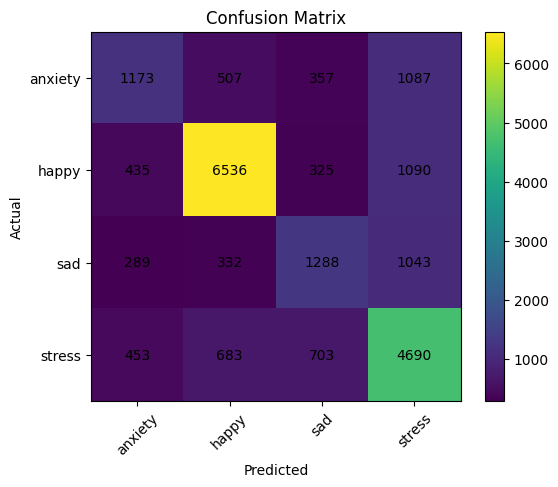

In [87]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

ticks = np.arange(len(le.classes_))
plt.xticks(ticks, le.classes_, rotation=45)
plt.yticks(ticks, le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

### LSTM Model

In [93]:
from tensorflow.keras.models import Sequential

In [94]:
from tensorflow.keras.layers import LSTM,Dense,Embedding,Bidirectional,Dropout

In [95]:
l_model=Sequential()

In [96]:
l_model.add(Embedding(20000, 128, input_length=40))

In [97]:
l_model.add(Bidirectional(LSTM(128,return_sequences=True)))

In [98]:
l_model.add(Dropout(0.5))

In [99]:
l_model.add(Bidirectional(LSTM(64)))

In [100]:
l_model.add(Dense(units=64,activation='relu'))

In [101]:
l_model.add(Dropout(0.5))

In [102]:
l_model.add(Dense(units=4,activation='softmax'))

### LSTM Compiler

In [103]:
l_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [104]:
l_model.fit(x_train,y_train,epochs=10)

Epoch 1/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 122s 45ms/step - accuracy: 0.6306 - loss: 0.9480
Epoch 2/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 121s 46ms/step - accuracy: 0.7043 - loss: 0.7916
Epoch 3/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 126s 48ms/step - accuracy: 0.7296 - loss: 0.7233
Epoch 4/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 121s 46ms/step - accuracy: 0.7480 - loss: 0.6654
Epoch 5/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 123s 47ms/step - accuracy: 0.7594 - loss: 0.6167
Epoch 6/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 121s 46ms/step - accuracy: 0.7700 - loss: 0.5752
Epoch 7/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 120s 46ms/step - accuracy: 0.7770 - loss: 0.5413
Epoch 8/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 121s 46ms/step - accuracy: 0.7831 - loss: 0.5134
Epoch 9/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 121s 46ms/step - accuracy: 0.7877 - loss: 0.4910
Epoch 10/10
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 121s 46ms/step - accuracy: 0.7892 - loss: 0.4725


In [105]:
y_pred1= l_model.predict(x_test)

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step


In [106]:
y_pred1

array([[1.4977534e-01, 6.5500981e-01, 1.5207055e-02, 1.8000777e-01],
       [1.9317439e-01, 2.9010805e-01, 2.1294051e-01, 3.0377704e-01],
       [1.1163769e-02, 6.2761426e-01, 1.0231327e-01, 2.5890869e-01],
       ...,
       [7.0902010e-05, 9.9992645e-01, 4.7365702e-07, 2.1238384e-06],
       [3.8819978e-01, 8.1956394e-02, 2.0120119e-01, 3.2864270e-01],
       [3.4501954e-04, 2.2207369e-04, 7.9279725e-04, 9.9864012e-01]],
      shape=(20991, 4), dtype=float32)

In [107]:
y_pred_classes1= y_pred1.argmax(axis=1)

In [108]:
y_pred_classes1

array([1, 3, 1, ..., 1, 0, 3], shape=(20991,))

In [109]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [110]:
accuracy2=accuracy_score(y_test, y_pred_classes1)

In [111]:
accuracy2

0.6685722452479634

In [112]:
cr1=classification_report(y_test,y_pred_classes1,output_dict=True)

In [113]:
cr1

{'0': {'precision': 0.4915191740412979,
  'recall': 0.426696542893726,
  'f1-score': 0.4568197395476354,
  'support': 3124.0},
 '1': {'precision': 0.7626993346710318,
  'recall': 0.8611972334843787,
  'f1-score': 0.8089610753290395,
  'support': 8386.0},
 '2': {'precision': 0.541398116013882,
  'recall': 0.3699186991869919,
  'f1-score': 0.4395250553431274,
  'support': 2952.0},
 '3': {'precision': 0.645811865155307,
  'recall': 0.6719252565477102,
  'f1-score': 0.6586098183455937,
  'support': 6529.0},
 'accuracy': 0.6685722452479634,
 'macro avg': {'precision': 0.6103571224703797,
  'recall': 0.5824344330282016,
  'f1-score': 0.5909789221413491,
  'support': 20991.0},
 'weighted avg': {'precision': 0.6548623422575516,
  'recall': 0.6685722452479634,
  'f1-score': 0.6578340198850665,
  'support': 20991.0}}

In [114]:
pd.DataFrame(cr1)

,0,1,2,3,accuracy,macro avg,weighted avg
precision,0.491519,0.762699,0.541398,0.645812,0.668572,0.610357,0.654862
recall,0.426697,0.861197,0.369919,0.671925,0.668572,0.582434,0.668572
f1-score,0.456820,0.808961,0.439525,0.658610,0.668572,0.590979,0.657834
support,3124.000000,8386.000000,2952.000000,6529.000000,0.668572,20991.000000,20991.000000


In [115]:
cm2 = confusion_matrix(y_test, y_pred_classes1)

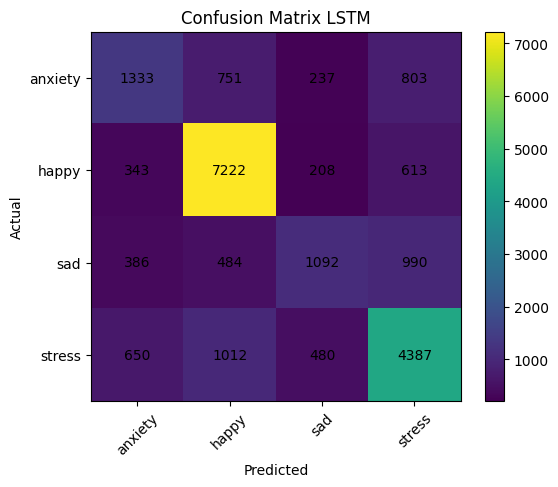

In [116]:
plt.figure()
plt.imshow(cm2)
plt.title("Confusion Matrix LSTM")
plt.colorbar()

ticks = np.arange(len(le.classes_))
plt.xticks(ticks, le.classes_, rotation=45)
plt.yticks(ticks, le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i, j], ha="center", va="center")

plt.show()

In [117]:
def predict(text):
    text = " ".join([w.lower() for w in text.split()])

    seq = tokenizer.texts_to_sequences([text])
    pad = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=30)

    y_pred = model.predict(pad)
    pred_class = y_pred.argmax(axis=1)[0]
    return le.inverse_transform([y_pred.argmax()])[0]

print(predict('that game hurt'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
sad


In [119]:
model.save("emotion_model.h5")


In [120]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [121]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)